In [ ]:
import datetime
import os
import ee
import geemap
import joblib
import matplotlib.pyplot as plt

from identify_locations import identify_forests, identify_route_buffer
from read_and_process_hls import compute_hls_indices
from fit_greendown_curves import compute_transition_dates, compute_average_transition_dates
from filter_ci_widths import count_narrow_ci_pixel_years
from build_data_table import build_feature_table, export_prediction_avg_assets
from edit_data_table import edit_feature_table
from plot_feature_distributions import plot_feature_distributions
from decision_trees import split_data, fit_tree

from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn import tree

ee.Initialize(project='turnkey-lacing-391919')

OUTPUT_DIR = './greendown_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

start_year    = 2013  # First HLS year
download_year = 2025  # Last year to download (includes 2025 for prediction)
train_year    = 2024  # Last year included in model training

# ----------------------------
# Fit logistic curves for each year (download all years including 2025)
# ----------------------------
all_year_paths = []
for y in range(start_year, download_year + 1):
    print(f'Processing {y}...')
    hls   = compute_hls_indices(route_buffer, ma_forest, y)
    paths = compute_transition_dates(hls, route_buffer, ma_forest, y, output_dir=OUTPUT_DIR)
    all_year_paths.append(paths)

prev_year_paths = all_year_paths[-1]   # most recent year

# ----------------------------
# Average transition dates across all years
# ----------------------------
print('Computing averages...')
avg_paths = compute_average_transition_dates(all_year_paths, output_dir=OUTPUT_DIR)

# ----------------------------
# Export committed assets the live (Action) prediction needs for
# doy_minus_avg_middle: the CI-filtered per-pixel cross-year average and the
# global gap-fill scalar. Re-run on every retrain, then commit:
#   greendown_middle_avg_filtered.tif, greendown_avg_meta.json
# ----------------------------
print('\nExporting prediction average assets...')
export_prediction_avg_assets(OUTPUT_DIR)

# ----------------------------
# Filter: pixels with CI width < 15 days for all transitions
# ----------------------------
print('\nFiltering pixel-years by CI width...')
years = list(range(start_year, download_year + 1))
count_narrow_ci_pixel_years(OUTPUT_DIR, years)

# ----------------------------
# Build labeled EVI/NDVI feature table (training years only: 2013–2024)
# ----------------------------
print('\nBuilding labeled feature table...')
training_years = list(range(start_year, train_year + 1))
feature_df = build_feature_table(OUTPUT_DIR, training_years)
#plot_feature_distributions(feature_df)
feature_df_edited = edit_feature_table(feature_df, OUTPUT_DIR)
print(feature_df_edited.head())
print('\nNaN counts per column:')
print(feature_df_edited.isna().sum())
#plot_feature_distributions(feature_df_edited)

12
29
29
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 12, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 29, 'min_samples_split': 29, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 1234, 'splitter': 'best'}
Model saved to ./greendown_outputs/decision_tree_model.joblib


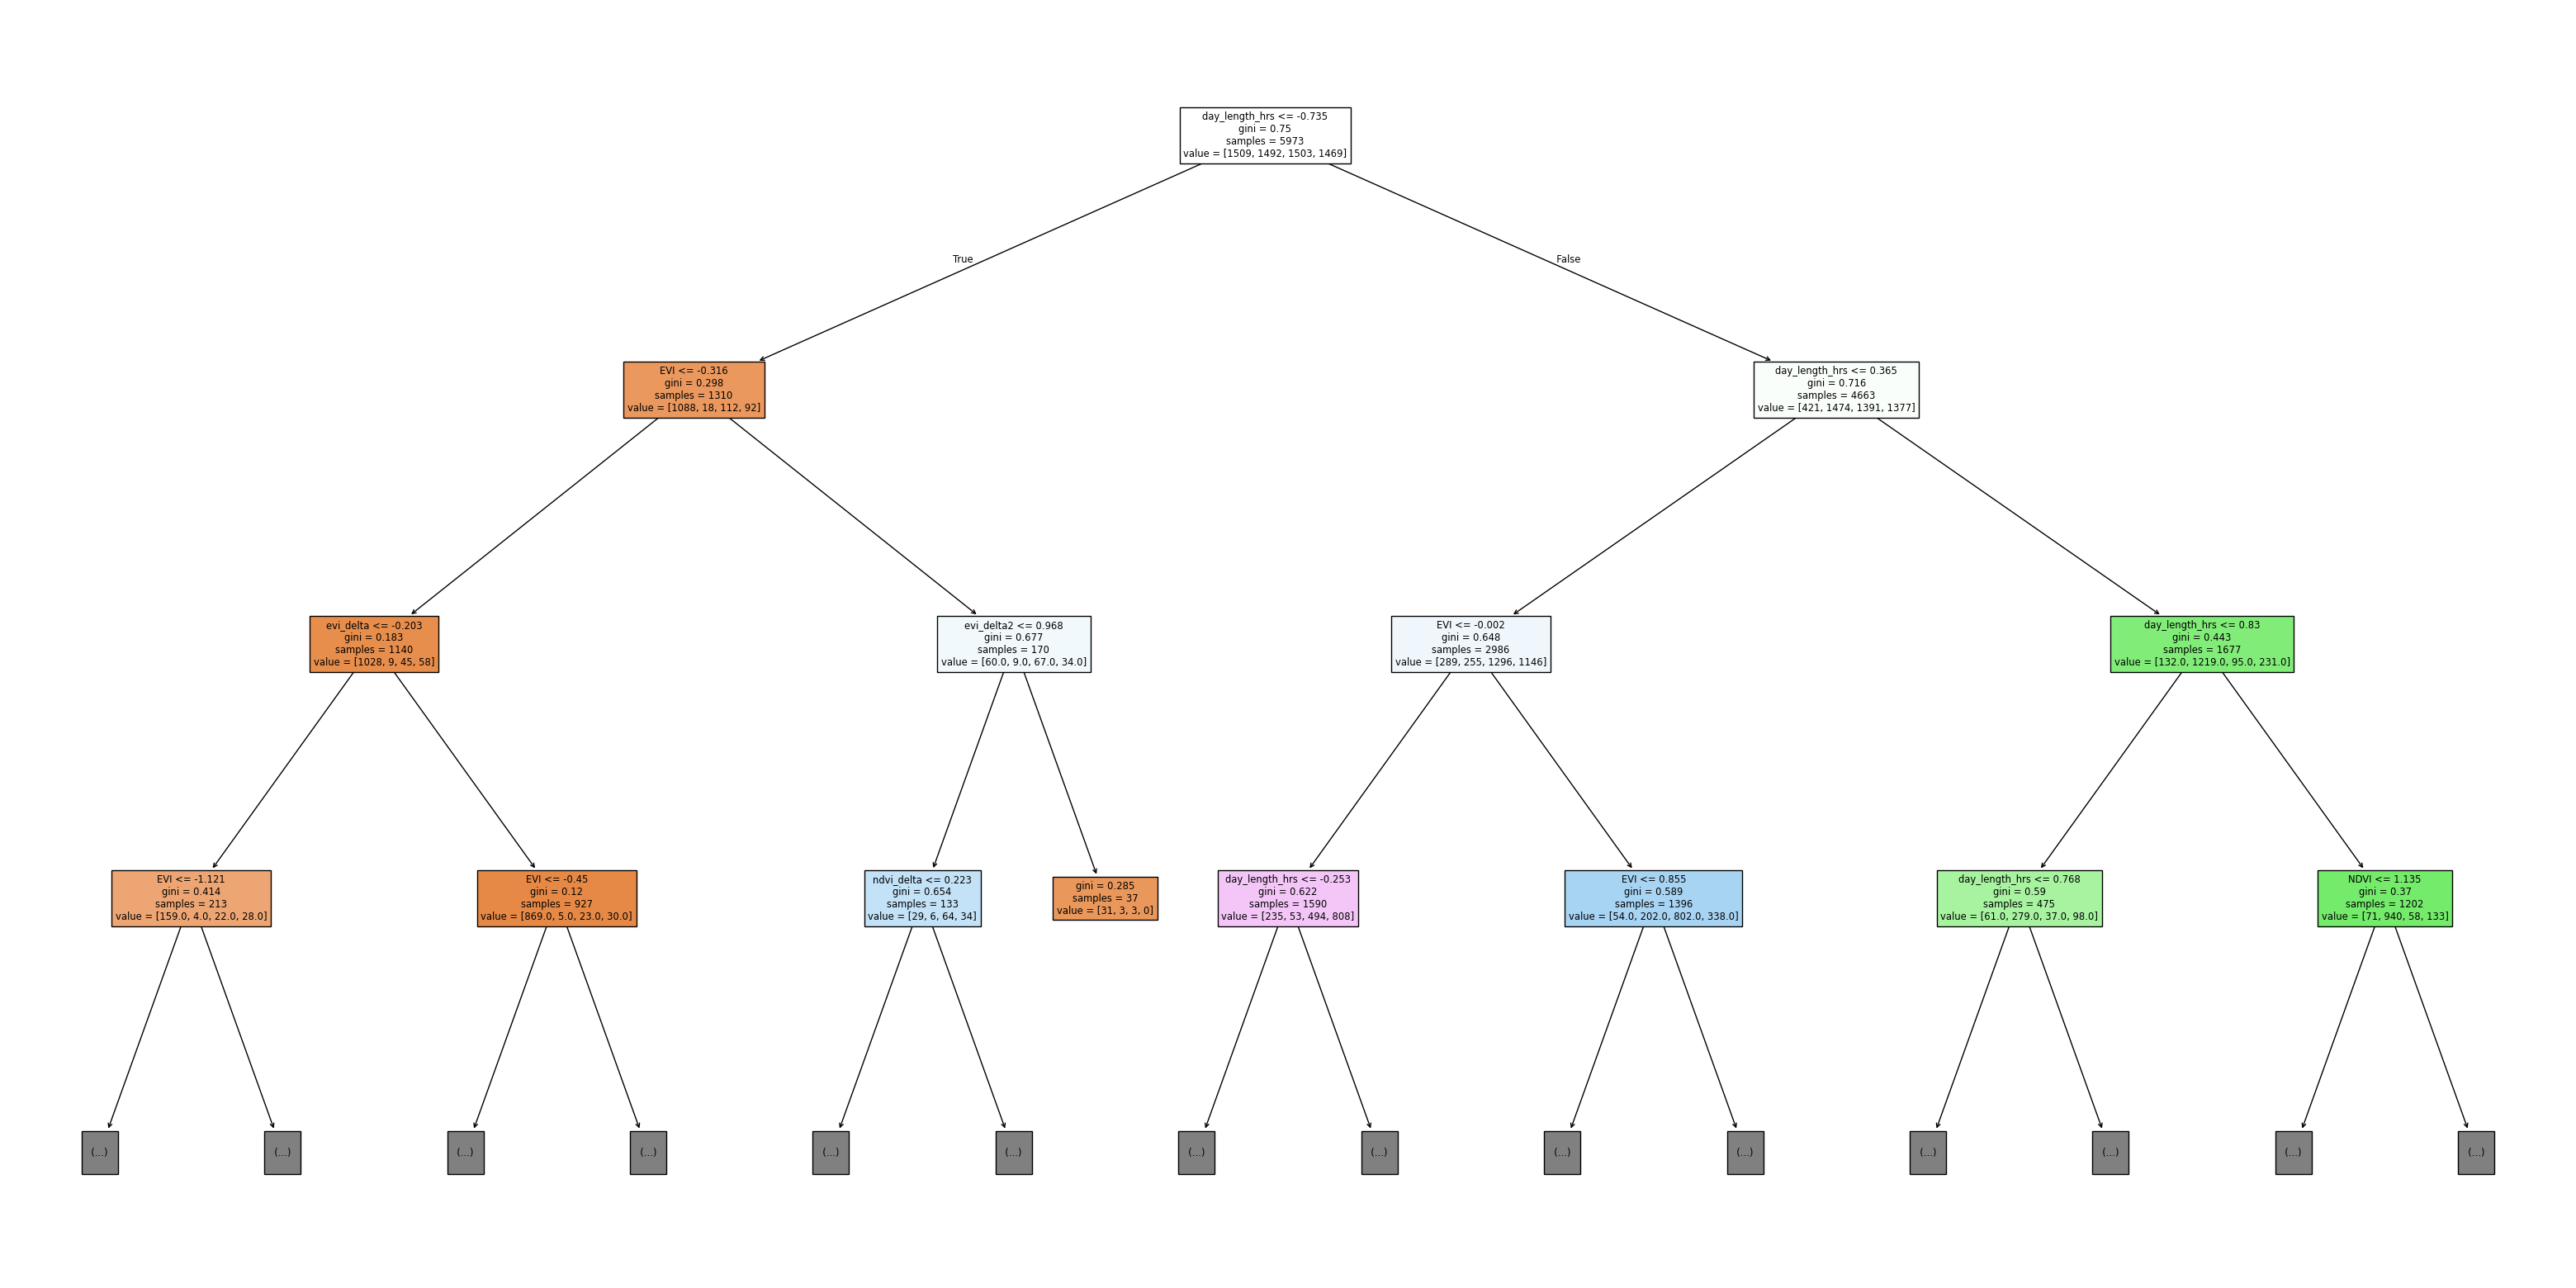

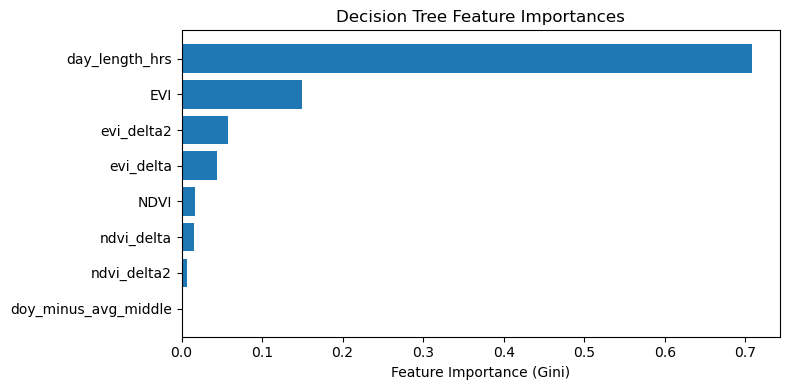


Test Accuracy Score:
0.7332998493219488
              precision    recall  f1-score   support

       after       0.85      0.86      0.86       482
      before       0.73      0.85      0.79       499
       early       0.69      0.65      0.67       488
        late       0.65      0.59      0.62       522

    accuracy                           0.73      1991
   macro avg       0.73      0.74      0.73      1991
weighted avg       0.73      0.73      0.73      1991


Train Accuracy Score:
0.7774987443495731
              precision    recall  f1-score   support

       after       0.86      0.84      0.85      1509
      before       0.78      0.87      0.82      1492
       early       0.78      0.71      0.74      1503
        late       0.70      0.68      0.69      1469

    accuracy                           0.78      5973
   macro avg       0.78      0.78      0.78      5973
weighted avg       0.78      0.78      0.78      5973



In [2]:
# ----------------------------
# Build decision tree
# ----------------------------
x_train, x_test, y_train, y_test = split_data(feature_df_edited)

mdl = fit_tree(x_train, y_train, True)
print(mdl.get_depth())
print(mdl.min_samples_split)
print(mdl.min_samples_leaf)
print(mdl.get_params())

# Save model for dashboard use
joblib.dump(mdl, os.path.join(OUTPUT_DIR, 'decision_tree_model.joblib'))
print(f'Model saved to {OUTPUT_DIR}/decision_tree_model.joblib')

# ----------------------------
# Visualize decision tree
# ----------------------------
fig, ax = plt.subplots(figsize=(40, 20))
tree.plot_tree(mdl, feature_names=list(x_train.columns), filled=True, max_depth=3, ax=ax)
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()

# Plot feature importances
importances = mdl.feature_importances_
feature_names = list(x_train.columns)
sorted_idx = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_names) * 0.4)))
ax.barh([feature_names[i] for i in sorted_idx], [importances[i] for i in sorted_idx])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree Feature Importances')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'feature_importances.png'), dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# Test on test data
# ----------------------------
y_pred = mdl.predict(x_test)

# ----------------------------
# Evaluate model
# ----------------------------
print('\nTest Accuracy Score:')
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Check for overfitting by comparing accuracy of predicting training data to predicting test data
y_pred_train = mdl.predict(x_train)
print('\nTrain Accuracy Score:')
print(accuracy_score(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))
#Take-away: without pruning the accuracy on the training data is 1 and the accuracy on the testing data in 0.75 so the model is overfitting
    #With pruning the test accuracy is 0.74 and training is 0.78 so much closer and less overfitting